100%|██████████| 100/100 [00:08<00:00, 11.30it/s]


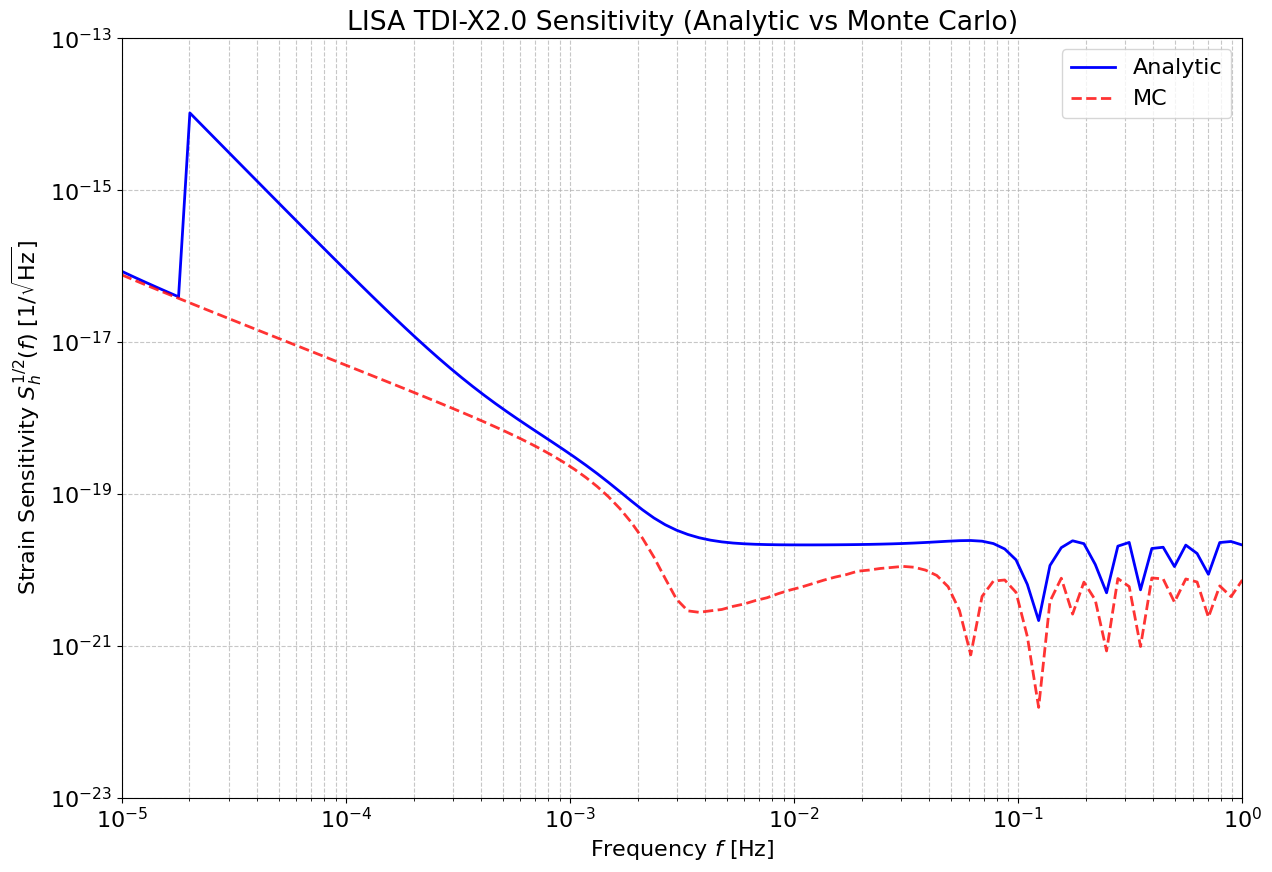

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
plt.rcParams.update({'font.size': 16})

c = 299792458.0
L = 2.5e9
f = np.logspace(-5, 0, 100)
x = 2 * np.pi * f * L / c

# LISA仪器噪声
S_pos = (15e-12)**2 * (1 + (2e-3 / f)**4)

S_a = (3e-15)**2 * (1 + (0.4e-3 / f)**2) * (1 + (f / 8e-3)**4)
S_acc_pos = S_a / (2 * np.pi * f)**4

S_n_X2_inst = 64 * (np.sin(0.5 * x))**2 * (np.sin(x))**2 * \
               (S_pos + (2 + 2 * np.cos(x)**2) * S_acc_pos)

# 前景混淆噪声
A_conf = 1.14e-44     # 振幅
alpha_conf = 2.0      # 指数
f0_conf = 1.14e-3     # 特征频率
S_c = A_conf * (f ** (-7/3)) * np.exp(-(f / f0_conf)**alpha_conf)

# 半解析方法
R_ana = np.zeros_like(x)
mask = x >= 1e-3
R_ana[mask] = 4 * (L**2) * (np.sin(x[mask]))**2 * (1 - np.sin(x[mask])**2 / (x[mask])**2)
R_ana[~mask] = (4/3) * (L**2) * (x[~mask])**2
# 总应变噪声 = 仪器噪声 + 混淆噪声
S_h_ana = np.sqrt((S_n_X2_inst / R_ana) + S_c)

# MC
def compute_R_mc(f_sample, N=2000):
    n1 = np.array([1, 0, 0])
    n2 = np.array([0.5, np.sqrt(3)/2, 0])
    z = np.array([0, 0, 1])

    R_num = np.zeros_like(f_sample)

    for i, fi in enumerate(tqdm(f_sample)):
        xi = 2 * np.pi * fi * L / c
        total = 0.0

        for _ in range(N):
            # 随机方向
            theta = np.arccos(1 - 2*np.random.rand())
            phi = 2*np.pi*np.random.rand()
            psi = 2*np.pi*np.random.rand()

            k = np.array([
                np.sin(theta)*np.cos(phi),
                np.sin(theta)*np.sin(phi),
                np.cos(theta)
            ])

            # 极化基
            u = np.cross(z, k)
            if np.linalg.norm(u) < 1e-10:
                u = np.array([1, 0, 0])
            u /= np.linalg.norm(u)
            v = np.cross(k, u)

            e_plus = np.outer(u, u) - np.outer(v, v)
            e_cross = np.outer(u, v) + np.outer(v, u)

            # 极化旋转
            e_plus_rot = np.cos(2*psi)*e_plus + np.sin(2*psi)*e_cross
            e_cross_rot = -np.sin(2*psi)*e_plus + np.cos(2*psi)*e_cross

            # 单链路响应
            D1 = 1 - np.dot(k, n1)
            D2 = 1 - np.dot(k, n2)

            # 避免除0
            if abs(D1) < 1e-8:
                D1 = 1e-8
            if abs(D2) < 1e-8:
                D2 = 1e-8

            T1 = (1 - np.exp(-1j * xi * D1)) / D1
            T2 = (1 - np.exp(-1j * xi * D2)) / D2

            Fp = (n1 @ e_plus_rot @ n1) * T1 - (n2 @ e_plus_rot @ n2) * T2
            Fc = (n1 @ e_cross_rot @ n1) * T1 - (n2 @ e_cross_rot @ n2) * T2

            total += (np.abs(Fp)**2 + np.abs(Fc)**2)

        R_num[i] = 4 * (L**2) * (total / N)

    return R_num


R_mc = compute_R_mc(f, N=1500)

S_h_mc = np.sqrt((S_n_X2_inst / R_mc) + S_c)

plt.figure(figsize=(13, 9))
plt.loglog(f, S_h_ana, 'b-', linewidth=2, label='Analytic')
plt.loglog(f, S_h_mc, 'r--', linewidth=2, label='MC', alpha=0.8)

plt.xlabel('Frequency $f$ [Hz]')
plt.ylabel(r'Strain Sensitivity $S_h^{1/2}(f)$ [$1/\sqrt{\mathrm{Hz}}$]')
plt.title('LISA TDI-X2.0 Sensitivity (Analytic vs Monte Carlo)')

plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend()
plt.xlim(1e-5, 1e0)
plt.ylim(1e-23, 1e-13)

plt.tight_layout()
plt.show()